# Restarted neural cascade for the singular FBSDE

## Setup

In [1]:
from __future__ import annotations

import copy
import dataclasses
import math
import random
from contextlib import contextmanager
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import Tensor, nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
SEED = 123

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

print("device", DEVICE)

device cuda


In [2]:
@dataclass(frozen=True)
class Config:
    T: float = 1.0
    sigma: float = 1.0
    alpha: float = 1.0

    x_min: float = 1.0
    n2_x_max: float = 4.0
    n3_x_max: float = 7.0
    max_restart_time: float = 0.95

    steps: int = 40
    restart_levels: int = 41

    width: int = 64
    depth: int = 3
    iterations: int = 15_000
    batch_size: int = 1_024
    validation_size: int = 8_192

    learning_rate: float = 1.0e-3
    scheduler_step: int = 1_000
    scheduler_gamma: float = 0.95
    validation_every: int = 200
    display_every: int = 2_000
    gradient_clip: float = 10.0

    living_weight: float = 0.10
    exit_weight: float = 0.10
    range_weight: float = 0.05
    monotonicity_weight: float = 0.25

    terminal_epsilon: float = 0.01
    terminal_guard_std: float = 4.0

    boundary_zero_tol: float = 5.0e-5
    boundary_other_margin: float = 1.0e-4
    boundary_rounds: int = 400
    boundary_multiplier: int = 4

    validation_times: tuple[float, ...] = (0.0, 0.5, 0.9, 0.95)

    reference_grid: int = 51
    reference_paths: int = 2_048
    reference_steps: tuple[int, ...] = (40, 400, 4_000)
    reference_point_batch: int = 256
    bootstrap_reps: int = 200

    perturbation: float = 0.05

    projection_samples: int = 4_096
    projection_far: tuple[float, ...] = (6.0, 6.5, 7.0)

    kink_samples: int = 1_000_000
    kink_chunk_size: int = 100_000
    kink_tolerance: float = 0.05

    leakage_samples: int = 32_768
    leakage_chunk_size: int = 8_192
    boundary_leakage_samples: int = 8_192
    boundary_leakage_chunk_size: int = 2_048

    seed_study_seeds: tuple[int, ...] = (123, 20_001, 30_002)
    volatility_sigma: float = 0.30
    volatility_x_max: float = 3.20

    @property
    def terminal_margin(self) -> float:
        return self.terminal_guard_std * self.sigma * math.sqrt(self.terminal_epsilon)

    @property
    def singleton_window(self) -> float:
        return 2.0 * self.sigma * math.sqrt(self.T)


CFG = Config()


@contextmanager
def override_config(**changes):
    global CFG
    saved = CFG
    CFG = dataclasses.replace(CFG, **changes)
    try:
        yield CFG
    finally:
        CFG = saved

## Helpers

In [3]:
def seed_all(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_generator(seed: int) -> torch.Generator:
    try:
        g = torch.Generator(device=DEVICE)
    except TypeError:
        g = torch.Generator()
    g.manual_seed(seed)
    return g


def permutation(size: int, generator: torch.Generator) -> Tensor:
    return torch.rand(size, generator=generator, device=DEVICE, dtype=DTYPE).argsort()


def uniform(shape, low, high, generator):
    return low + (high - low) * torch.rand(
        shape, generator=generator, device=DEVICE, dtype=DTYPE
    )


def normal_cdf(x: Tensor) -> Tensor:
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def normal_pdf(x: Tensor) -> Tensor:
    return torch.exp(-0.5 * x.square()) / math.sqrt(2.0 * math.pi)


def to_numpy(x: Tensor) -> np.ndarray:
    return x.detach().cpu().numpy()


def masked_mean(x: Tensor, mask: Tensor) -> Tensor:
    if bool(mask.any()):
        return x[mask].mean()
    return x.sum() * 0.0


def first_true(mask: Tensor):
    hit = mask.any(dim=1)
    index = torch.arange(mask.shape[1], device=mask.device).expand_as(mask)
    first = torch.where(mask, index, mask.shape[1]).min(dim=1).values
    last = torch.full_like(first, mask.shape[1] - 1)
    return torch.where(hit, first, last), hit


def show(title: str, table: pd.DataFrame, decimals: int = 4) -> None:
    print()
    print(title)
    print(table.round(decimals).to_string(index=False))

## Value network

In [4]:
class MLP(nn.Module):
    def __init__(self, inputs: int, width: int, depth: int):
        super().__init__()
        layers = []
        current = inputs
        for _ in range(depth):
            layers += [nn.Linear(current, width), nn.Softplus()]
            current = width
        layers.append(nn.Linear(current, 1))
        self.net = nn.Sequential(*layers)

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)[:, 0]


class ValueNet(nn.Module):
    def __init__(self, n: int, level: int, x_max: float):
        super().__init__()
        self.n = n
        self.level = level
        self.x_max = x_max

        self.time_center = 0.5 * CFG.T
        self.time_scale = 0.5 * CFG.T
        self.x_center = 0.5 * (CFG.x_min + x_max)
        self.x_scale = 0.5 * (x_max - CFG.x_min)

        self.net = MLP(1 + level, CFG.width, CFG.depth)

    def features(self, t, x: Tensor) -> Tensor:
        if self.level == 1:
            x = x.reshape(-1, 1)

        t = torch.as_tensor(t, device=x.device, dtype=x.dtype)
        if t.ndim == 0:
            t = t.expand(x.shape[0])
        t = t.reshape(-1, 1)

        sorted_x = torch.sort(x, dim=1).values

        return torch.cat(
            (
                (t - self.time_center) / self.time_scale,
                (sorted_x - self.x_center) / self.x_scale,
            ),
            dim=1,
        )

    def value(self, t, x: Tensor) -> Tensor:
        return self.net(self.features(t, x))

    def value_and_z(self, t, x: Tensor, create_graph: bool):
        if self.level == 1:
            x = x.reshape(-1, 1)

        x_var = x.detach().clone().requires_grad_(True)
        value = self.value(t, x_var)
        grad = torch.autograd.grad(value.sum(), x_var, create_graph=create_graph)[0]

        return value, CFG.sigma * grad

## Restarted paths

In [5]:
@dataclass
class Batch:
    start_time: Tensor
    times: Tensor
    x0: Tensor
    paths: Tensor
    dW: Tensor
    bridge_u: Tensor


@dataclass
class LevelGenerators:
    path: torch.Generator
    boundary: torch.Generator
    terminal: torch.Generator
    shape: torch.Generator


def make_level_generators(seed: int) -> LevelGenerators:
    return LevelGenerators(
        path=make_generator(seed + 11),
        boundary=make_generator(seed + 23),
        terminal=make_generator(seed + 37),
        shape=make_generator(seed + 53),
    )


def restart_times(size: int, generator: torch.Generator) -> Tensor:
    grid = torch.linspace(
        0.0, CFG.max_restart_time, CFG.restart_levels, device=DEVICE, dtype=DTYPE
    )
    base, remainder = divmod(size, len(grid))

    pieces = []
    if base:
        pieces.append(grid.repeat(base))
    if remainder:
        pieces.append(grid[permutation(len(grid), generator)[:remainder]])

    times = torch.cat(pieces) if pieces else grid[:0]
    return times[permutation(size, generator)]


def rollout_lower_bound(n: int, level: int) -> float:
    # Level one is sampled inside its continuation region; higher levels use the full box.
    if level == 1:
        return CFG.alpha * n + 1.0e-3
    return CFG.x_min


def sample_batch(batch_size, level, x_max, generator, antithetic, x_low):
    if antithetic and batch_size % 2:
        raise ValueError("batch size must be even")

    base = batch_size // 2 if antithetic else batch_size

    start = restart_times(base, generator)
    x0 = uniform((base, level), x_low, x_max, generator)
    normal = torch.randn(
        base, CFG.steps, level, generator=generator, device=DEVICE, dtype=DTYPE
    )
    bridge_u = torch.rand(
        base, CFG.steps, level, generator=generator, device=DEVICE, dtype=DTYPE
    )

    if antithetic:
        start = torch.cat((start, start.clone()))
        x0 = torch.cat((x0, x0.clone()))
        normal = torch.cat((normal, -normal))
        bridge_u = torch.cat((bridge_u, bridge_u.clone()))

    dt = (CFG.T - start) / CFG.steps
    dW = torch.sqrt(dt)[:, None, None] * normal

    zero = torch.zeros(batch_size, 1, level, device=DEVICE, dtype=DTYPE)
    paths = x0[:, None, :] + CFG.sigma * torch.cat((zero, dW.cumsum(dim=1)), dim=1)

    fraction = torch.arange(CFG.steps + 1, device=DEVICE, dtype=DTYPE)[None, :] / CFG.steps
    times = start[:, None] + (CFG.T - start)[:, None] * fraction

    return Batch(start, times, x0, paths, dW, bridge_u)

## Analytical singleton

In [6]:
@torch.no_grad()
def exact_singleton(n: int, t, x: Tensor) -> Tensor:
    t = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t, x = torch.broadcast_tensors(t, x)

    threshold = CFG.alpha * n
    remaining = CFG.T - t

    terminal = torch.where(
        x <= threshold,
        torch.full_like(x, float(n)),
        torch.full_like(x, float(n - 1)),
    )

    safe = remaining.clamp_min(torch.finfo(x.dtype).eps)
    arg = torch.clamp((threshold - x) / (CFG.sigma * torch.sqrt(safe)), max=0.0)

    return torch.where(
        remaining <= 1.0e-12, terminal, float(n - 1) + 2.0 * normal_cdf(arg)
    )


@torch.no_grad()
def exact_singleton_z(n: int, t, x: Tensor) -> Tensor:
    t = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t, x = torch.broadcast_tensors(t, x)

    threshold = CFG.alpha * n
    remaining = CFG.T - t
    safe = remaining.clamp_min(torch.finfo(x.dtype).eps)

    arg = (threshold - x) / (CFG.sigma * torch.sqrt(safe))
    z = -2.0 * normal_pdf(arg) / torch.sqrt(safe)

    return torch.where(
        (x <= threshold) | (remaining <= 1.0e-12), torch.zeros_like(x), z
    )


class FrozenSingleton:
    # Analytical singleton, optionally shifted by a known amount, exposed as a frozen model.
    def __init__(self, n: int, shift: float = 0.0):
        self.n = n
        self.shift = shift

    @torch.no_grad()
    def value(self, t, x: Tensor) -> Tensor:
        return exact_singleton(self.n, t, x.reshape(-1)) + self.shift

## Near-terminal guard

In [7]:
guard_excess = 2.0 * float(normal_cdf(torch.tensor(-CFG.terminal_guard_std)))
naive_excess = 2.0 * float(
    normal_cdf(torch.tensor(-0.05 / (CFG.sigma * math.sqrt(CFG.terminal_epsilon))))
)

print("near-terminal time       ", CFG.T - CFG.terminal_epsilon)
print("spatial guard            ", CFG.terminal_margin)
print("guard in diffusive s.d.  ", CFG.terminal_guard_std)
print("singleton excess at guard", guard_excess)
print("singleton excess at 0.05 ", naive_excess)

assert guard_excess < 1.0e-4

near-terminal time        0.99
spatial guard             0.4
guard in diffusive s.d.   4.0
singleton excess at guard 6.335973739624023e-05
singleton excess at 0.05  0.6170750856399536


## Completion and learned geometry

In [8]:
@torch.no_grad()
def completed_value(n, level, t, x, models):
    if level == 0:
        return torch.full((x.shape[0],), float(n), device=x.device, dtype=x.dtype)

    tt = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    if tt.ndim == 0:
        tt = tt.expand(x.shape[0])
    at_terminal = tt >= CFG.T - 1.0e-10

    if level == 1:
        raw = models[1].value(t, x[:, 0])
        raw = torch.where(at_terminal, torch.full_like(raw, float(n - 1)), raw)
        return torch.where(x[:, 0] <= CFG.alpha * n, torch.full_like(raw, float(n)), raw)

    raw = models[level].value(t, x)
    raw = torch.where(at_terminal, torch.full_like(raw, float(n - level)), raw)

    lower_raw, margins = [], []
    for i in range(level):
        reduced = torch.cat((x[:, :i], x[:, i + 1:]), dim=1)
        lower = completed_value(n, level - 1, t, reduced, models)
        geometry = lower.clamp(float(n - level + 1), float(n))
        lower_raw.append(lower)
        margins.append(x[:, i] - CFG.alpha * geometry)

    lower_raw = torch.stack(lower_raw, dim=1)
    margins = torch.stack(margins, dim=1)

    inside = (margins > 0.0).all(dim=1)
    selected = margins.argmin(dim=1)
    boundary_value = lower_raw.gather(1, selected[:, None])[:, 0]

    return torch.where(inside, raw, boundary_value)


@torch.no_grad()
def margins_at(n, level, t, x, lower_models):
    if level == 1:
        return x[:, 0:1] - CFG.alpha * n

    margins = []
    for i in range(level):
        reduced = torch.cat((x[:, :i], x[:, i + 1:]), dim=1)
        lower = completed_value(n, level - 1, t, reduced, lower_models)
        geometry = lower.clamp(float(n - level + 1), float(n))
        margins.append(x[:, i] - CFG.alpha * geometry)

    return torch.stack(margins, dim=1)


@torch.no_grad()
def in_domain(n, level, t, x, lower_models):
    return (margins_at(n, level, t, x, lower_models) > 0.0).all(dim=1)

## Brownian-bridge stopping

In [9]:
@torch.no_grad()
def stop_target(n, level, batch, lower_models, use_bridge):
    b, nodes, _ = batch.paths.shape
    flat_t = batch.times.reshape(-1)

    if level == 1:
        margin = batch.paths[:, :, 0] - CFG.alpha * n
        all_margins = margin[:, :, None]
        all_lower = torch.full_like(all_margins, float(n))
    else:
        margin_list, lower_list = [], []
        for i in range(level):
            reduced = torch.cat(
                (batch.paths[:, :, :i], batch.paths[:, :, i + 1:]), dim=2
            ).reshape(-1, level - 1)

            lower = completed_value(
                n, level - 1, flat_t, reduced, lower_models
            ).reshape(b, nodes)
            geometry = lower.clamp(float(n - level + 1), float(n))

            margin_list.append(batch.paths[:, :, i] - CFG.alpha * geometry)
            lower_list.append(lower)

        all_margins = torch.stack(margin_list, dim=2)
        all_lower = torch.stack(lower_list, dim=2)

    immediate = all_margins[:, 0] <= 0.0

    if use_bridge:
        left = all_margins[:, :-1]
        right = all_margins[:, 1:]
        both_above = (left > 0.0) & (right > 0.0)

        dt = ((CFG.T - batch.start_time) / CFG.steps)[:, None, None]
        q = torch.where(
            both_above,
            torch.exp(
                -2.0
                * left.clamp_min(0.0)
                * right.clamp_min(0.0)
                / (CFG.sigma**2 * dt.clamp_min(torch.finfo(DTYPE).eps))
            ).clamp(0.0, 1.0),
            torch.zeros_like(left),
        )

        interval_fire = (right <= 0.0) | (both_above & (batch.bridge_u <= q))
    else:
        interval_fire = all_margins[:, 1:] <= 0.0

    fired = torch.zeros(b, nodes, level, device=DEVICE, dtype=torch.bool)
    fired[:, 0] = immediate
    fired[:, 1:] = interval_fire

    stop_index, hit = first_true(fired.any(dim=2))

    row = torch.arange(b, device=DEVICE)
    stop_margins = all_margins[row, stop_index]
    stop_fired = fired[row, stop_index]

    masked = torch.where(
        stop_fired, stop_margins, torch.full_like(stop_margins, math.inf)
    )
    selected = masked.argmin(dim=1)

    exit_value = all_lower[row, stop_index].gather(1, selected[:, None])[:, 0]
    terminal = torch.full_like(exit_value, float(n - level))

    return stop_index, torch.where(hit, exit_value, terminal), hit

## Training data

In [10]:
@torch.no_grad()
def sample_boundary(n, level, x_max, lower_models, generator, size):
    if level == 1:
        t = restart_times(size, generator)
        point = torch.full((size, 1), CFG.alpha * n, device=DEVICE, dtype=DTYPE)
        target = torch.full((size,), float(n), device=DEVICE, dtype=DTYPE)
        return t, point, target

    times, points, targets = [], [], []
    needed = size

    for _ in range(CFG.boundary_rounds):
        if needed <= 0:
            break

        proposal = max(CFG.boundary_multiplier * needed, 128)
        t = restart_times(proposal, generator)
        survivor = uniform((proposal, level - 1), CFG.x_min, x_max, generator)

        keep = in_domain(n, level - 1, t, survivor, lower_models)
        if not bool(keep.any()):
            continue

        t = t[keep]
        survivor = survivor[keep]

        lower = completed_value(n, level - 1, t, survivor, lower_models)
        geometry = lower.clamp(float(n - level + 1), float(n))
        point = torch.cat(((CFG.alpha * geometry)[:, None], survivor), dim=1)

        current = margins_at(n, level, t, point, lower_models)
        valid = (current[:, 0].abs() <= CFG.boundary_zero_tol) & (
            current[:, 1:] > CFG.boundary_other_margin
        ).all(dim=1)

        if not bool(valid.any()):
            continue

        rows = valid.nonzero(as_tuple=False).flatten()[:needed]
        times.append(t[rows])
        points.append(point[rows])
        targets.append(lower[rows])
        needed -= len(rows)

    if needed > 0:
        raise RuntimeError("not enough boundary points")

    return (
        torch.cat(times)[:size],
        torch.cat(points)[:size],
        torch.cat(targets)[:size],
    )


@torch.no_grad()
def sample_terminal_points(n, level, x_max, lower_models, generator, size):
    t = CFG.T - CFG.terminal_epsilon

    if level == 1:
        low = CFG.alpha * n + CFG.terminal_margin
        if low >= x_max:
            raise ValueError("near-terminal guard leaves no sampling interval")
        return uniform((size, 1), low, x_max, generator)

    accepted = []
    needed = size

    for _ in range(200):
        if needed <= 0:
            break

        proposal = max(4 * needed, 128)
        x = uniform((proposal, level), CFG.x_min, x_max, generator)
        keep = (margins_at(n, level, t, x, lower_models) > CFG.terminal_margin).all(dim=1)

        if bool(keep.any()):
            rows = keep.nonzero(as_tuple=False).flatten()[:needed]
            accepted.append(x[rows])
            needed -= len(rows)

    if needed > 0:
        raise RuntimeError("not enough near-terminal points")

    return torch.cat(accepted)[:size]


def sample_level_data(n, level, x_max, lower_models, generators, batch_size, antithetic):
    batch = sample_batch(
        batch_size,
        level,
        x_max,
        generators.path,
        antithetic,
        rollout_lower_bound(n, level),
    )
    boundary = sample_boundary(
        n, level, x_max, lower_models, generators.boundary, batch_size
    )
    terminal = sample_terminal_points(
        n, level, x_max, lower_models, generators.terminal, batch_size
    )
    shape_t = restart_times(batch_size, generators.shape)
    shape_x = uniform((batch_size, level), CFG.x_min, x_max, generators.shape)

    return batch, boundary, terminal, shape_t, shape_x

## Loss

In [11]:
def path_values_and_z(model: ValueNet, batch: Batch):
    b, nodes, level = batch.paths.shape

    value, z = model.value_and_z(
        batch.times.reshape(-1),
        batch.paths.reshape(-1, level),
        create_graph=model.training,
    )

    return value.reshape(b, nodes), z.reshape(b, nodes, level)


def level_loss(n, level, model, lower_models, data, use_bridge):
    batch, boundary, terminal_x, shape_t, shape_x = data

    with torch.no_grad():
        stop_index, target, hit = stop_target(n, level, batch, lower_models, use_bridge)

    values, z = path_values_and_z(model, batch)
    increment = (z[:, :-1] * batch.dW).sum(dim=2)
    interval = torch.arange(CFG.steps, device=DEVICE)[None, :]

    before_stop = interval < stop_index[:, None]
    stopped = values[:, 0] + (increment * before_stop.to(DTYPE)).sum(dim=1)
    stopped_error = (stopped - target).square()

    immediate_exit = hit & (stop_index == 0)
    living = (~hit)[:, None] | ((interval + 1) < stop_index[:, None])
    exit_interval = hit[:, None] & ((interval + 1) == stop_index[:, None])

    one_step = values[:, :-1] + increment

    # A path surviving to T targets the exact completed terminal value.
    living_target = values[:, 1:].clone()
    living_target[:, -1] = float(n - level)

    living_loss = masked_mean((one_step - living_target).square(), living)
    exit_loss = masked_mean((one_step - target[:, None]).square(), exit_interval)

    boundary_t, boundary_x, boundary_target = boundary
    boundary_loss = (model.value(boundary_t, boundary_x) - boundary_target).square().mean()

    terminal_value = model.value(CFG.T - CFG.terminal_epsilon, terminal_x)
    terminal_loss = (terminal_value - float(n - level)).square().mean()

    with torch.no_grad():
        shape_mask = in_domain(n, level, shape_t, shape_x, lower_models)

    shape_value, shape_z = model.value_and_z(
        shape_t, shape_x, create_graph=model.training
    )

    range_penalty = (
        torch.relu(float(n - level) - shape_value).square()
        + torch.relu(shape_value - float(n)).square()
    )
    monotonicity_penalty = torch.relu(shape_z / CFG.sigma).square().sum(dim=1)

    range_loss = masked_mean(range_penalty, shape_mask)
    monotonicity_loss = masked_mean(monotonicity_penalty, shape_mask)

    total = (
        stopped_error.mean()
        + CFG.living_weight * living_loss
        + CFG.exit_weight * exit_loss
        + boundary_loss
        + terminal_loss
        + CFG.range_weight * range_loss
        + CFG.monotonicity_weight * monotonicity_loss
    )

    parts = {
        "stopped": stopped_error.mean(),
        "stopped_immediate": masked_mean(stopped_error, immediate_exit),
        "stopped_rollout": masked_mean(stopped_error, stop_index > 0),
        "immediate_exit_fraction": immediate_exit.to(DTYPE).mean(),
        "living": living_loss,
        "exit": exit_loss,
        "boundary": boundary_loss,
        "near_terminal": terminal_loss,
        "range": range_loss,
        "monotonicity": monotonicity_loss,
        "shape_in_domain": shape_mask.to(DTYPE).mean(),
    }

    return total, parts

## Training

In [12]:
@dataclass
class TrainResult:
    best_iteration: int
    best_loss: float
    history: pd.DataFrame


def train_level(n, level, x_max, lower_models, seed, use_bridge, name):
    seed_all(seed)
    model = ValueNet(n, level, x_max).to(DEVICE)

    train_g = make_level_generators(seed + 1_000)
    val_g = make_level_generators(seed + 2_000)
    val_data = sample_level_data(
        n, level, x_max, lower_models, val_g, CFG.validation_size, False
    )

    optimiser = torch.optim.Adam(model.parameters(), lr=CFG.learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimiser, step_size=CFG.scheduler_step, gamma=CFG.scheduler_gamma
    )

    best_loss = math.inf
    best_iteration = 0
    best_state = copy.deepcopy(model.state_dict())
    rows = []

    for iteration in range(1, CFG.iterations + 1):
        model.train()
        data = sample_level_data(
            n, level, x_max, lower_models, train_g, CFG.batch_size, True
        )

        optimiser.zero_grad(set_to_none=True)
        loss, _ = level_loss(n, level, model, lower_models, data, use_bridge)

        if not torch.isfinite(loss):
            raise FloatingPointError(name)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.gradient_clip)
        optimiser.step()
        scheduler.step()

        if iteration % CFG.validation_every == 0 or iteration == CFG.iterations:
            model.eval()
            with torch.enable_grad():
                val_loss, parts = level_loss(
                    n, level, model, lower_models, val_data, use_bridge
                )

            value = float(val_loss.detach().cpu())
            row = {"iteration": iteration, "validation": value}
            row.update({k: float(v.detach().cpu()) for k, v in parts.items()})
            rows.append(row)

            if value < best_loss:
                best_loss = value
                best_iteration = iteration
                best_state = copy.deepcopy(model.state_dict())

            if iteration % CFG.display_every == 0 or iteration == CFG.iterations:
                print(name, iteration, f"{value:.4e}")

    model.load_state_dict(best_state)
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    return model, TrainResult(best_iteration, best_loss, pd.DataFrame(rows))


def train_cascade(n, x_max, seed):
    models, training = {}, {}

    for level in range(1, n + 1):
        lower = {k: v for k, v in models.items() if k < level}
        model, result = train_level(
            n, level, x_max, lower, seed + 100 * level, True, f"N {n} level {level}"
        )
        models[level] = model
        training[level] = result

    return models, training


def training_table(n, training):
    keys = [
        "stopped",
        "stopped_immediate",
        "stopped_rollout",
        "immediate_exit_fraction",
        "living",
        "exit",
        "boundary",
        "near_terminal",
        "range",
        "monotonicity",
        "shape_in_domain",
    ]

    rows = []
    for level, result in training.items():
        best = result.history.loc[result.history["validation"].idxmin()]
        row = {
            "N": n,
            "level": level,
            "best iteration": result.best_iteration,
            "best validation": result.best_loss,
        }
        row.update({k: float(best[k]) for k in keys})
        rows.append(row)

    return pd.DataFrame(rows)

## Diagnostics

In [13]:
@torch.no_grad()
def singleton_table(n, model, x_eval_max):
    x = torch.linspace(CFG.alpha * n + 0.001, x_eval_max, 800, device=DEVICE, dtype=DTYPE)

    rows = []
    for t in CFG.validation_times:
        error = model.value(t, x) - exact_singleton(n, t, x)

        with torch.enable_grad():
            _, z = model.value_and_z(t, x[:, None], create_graph=False)

        rows.append({
            "time": t,
            "MAE": error.abs().mean().item(),
            "RMSE": error.square().mean().sqrt().item(),
            "signed mean": error.mean().item(),
            "max error": error.abs().max().item(),
            "Z MAE": (z[:, 0] - exact_singleton_z(n, t, x)).abs().mean().item(),
        })

    return pd.DataFrame(rows)


@torch.no_grad()
def continuity_correction_table(n, x_eval_max, beta=0.5826):
    x = torch.linspace(CFG.alpha * n + 0.001, x_eval_max, 800, device=DEVICE, dtype=DTYPE)

    rows = []
    for t in CFG.validation_times:
        remaining = CFG.T - t
        shift = beta * CFG.sigma * math.sqrt(remaining / CFG.steps)
        arg = torch.clamp(
            (CFG.alpha * n - shift - x) / (CFG.sigma * math.sqrt(remaining)), max=0.0
        )
        predicted = float(n - 1) + 2.0 * normal_cdf(arg)
        rows.append({
            "time": t,
            "predicted grid MAE": (predicted - exact_singleton(n, t, x)).abs().mean().item(),
        })

    return pd.DataFrame(rows)


@torch.no_grad()
def kink_check(n, level, models, x_max, tol):
    g = make_generator(SEED + 30_000 + 100 * n + level)
    count, spread_sum, spread_max = 0, 0.0, 0.0

    for start in range(0, CFG.kink_samples, CFG.kink_chunk_size):
        size = min(CFG.kink_chunk_size, CFG.kink_samples - start)
        t = restart_times(size, g)
        x = uniform((size, level), CFG.x_min, x_max, g)

        values, margins = [], []
        for i in range(level):
            reduced = torch.cat((x[:, :i], x[:, i + 1:]), dim=1)
            lower = completed_value(n, level - 1, t, reduced, models)
            values.append(lower)
            margins.append(
                x[:, i] - CFG.alpha * lower.clamp(float(n - level + 1), float(n))
            )

        values = torch.stack(values, dim=1)
        margins = torch.stack(margins, dim=1)

        failed = margins <= 0.0
        if tol is not None:
            failed = failed & (margins >= -tol)

        rows = failed.sum(dim=1) >= 2
        if not bool(rows.any()):
            continue

        values = values[rows]
        failed = failed[rows]
        high = torch.where(failed, values, torch.full_like(values, -math.inf)).max(dim=1).values
        low = torch.where(failed, values, torch.full_like(values, math.inf)).min(dim=1).values
        spread = high - low

        count += int(rows.sum().item())
        spread_sum += spread.sum().item()
        spread_max = max(spread_max, spread.max().item())

    return {
        "N": n,
        "level": level,
        "tolerance": math.inf if tol is None else tol,
        "retained points": count,
        "mean spread": spread_sum / count if count else math.nan,
        "max spread": spread_max if count else math.nan,
    }


@torch.no_grad()
def leakage_summary(values, low, high, source):
    excursion = (values - values.clamp(low, high)).abs()
    leaked = excursion > 0.0

    return {
        "source": source,
        "count": int(values.numel()),
        "leak fraction": leaked.to(DTYPE).mean().item(),
        "mean excursion": excursion.mean().item(),
        "mean excursion given leak": excursion[leaked].mean().item() if bool(leaked.any()) else 0.0,
        "max excursion": excursion.max().item(),
    }


@torch.no_grad()
def leakage_diagnostic(n, level, models, x_max, seed):
    lower_models = {k: v for k, v in models.items() if k < level}
    low, high = float(n - level + 1), float(n)

    path_g = make_generator(seed + 1)
    chunks = []
    remaining = CFG.leakage_samples

    while remaining > 0:
        size = min(CFG.leakage_chunk_size, remaining)
        batch = sample_batch(
            size, level, x_max, path_g, False, rollout_lower_bound(n, level)
        )
        _, target, hit = stop_target(n, level, batch, lower_models, True)
        if bool(hit.any()):
            chunks.append(target[hit])
        remaining -= size

    exit_values = torch.cat(chunks) if chunks else torch.zeros(0, device=DEVICE, dtype=DTYPE)

    boundary_g = make_generator(seed + 2)
    boundary_chunks = []
    remaining = CFG.boundary_leakage_samples

    while remaining > 0:
        size = min(CFG.boundary_leakage_chunk_size, remaining)
        boundary_chunks.append(
            sample_boundary(n, level, x_max, lower_models, boundary_g, size)[2]
        )
        remaining -= size

    return pd.DataFrame([
        leakage_summary(exit_values, low, high, f"N{n} level{level} first-exit payoff"),
        leakage_summary(torch.cat(boundary_chunks), low, high, f"N{n} level{level} boundary target"),
    ])

## N = 2 cascade

In [14]:
grid_singleton, grid_training = train_level(
    2, 1, CFG.n2_x_max, {}, SEED + 100, False, "N 2 singleton grid"
)

models2, training2 = train_cascade(2, CFG.n2_x_max, SEED)

show("N = 2 training", training_table(2, training2))

N 2 singleton grid 2000 2.1652e-02
N 2 singleton grid 4000 1.7409e-02
N 2 singleton grid 6000 1.5176e-02
N 2 singleton grid 8000 1.4034e-02
N 2 singleton grid 10000 1.3362e-02
N 2 singleton grid 12000 1.2889e-02
N 2 singleton grid 14000 1.2925e-02
N 2 singleton grid 15000 1.2560e-02
N 2 level 1 2000 2.2923e-02
N 2 level 1 4000 1.9505e-02
N 2 level 1 6000 1.6122e-02
N 2 level 1 8000 1.5757e-02
N 2 level 1 10000 1.2882e-02
N 2 level 1 12000 1.2669e-02
N 2 level 1 14000 1.2015e-02
N 2 level 1 15000 1.1972e-02
N 2 level 2 2000 9.1895e-02
N 2 level 2 4000 4.8495e-02
N 2 level 2 6000 2.9838e-02
N 2 level 2 8000 2.5796e-02
N 2 level 2 10000 2.3176e-02
N 2 level 2 12000 2.2394e-02
N 2 level 2 14000 2.0586e-02
N 2 level 2 15000 2.0207e-02

N = 2 training
 N  level  best iteration  best validation  stopped  stopped_immediate  stopped_rollout  immediate_exit_fraction  living   exit  boundary  near_terminal  range  monotonicity  shape_in_domain
 2      1           14200           0.0119   0.0102  

### Structural checks

In [15]:
check_g = make_generator(SEED + 90_000)

plateau_x = uniform((20_000, 2), CFG.x_min, 2.0 * CFG.alpha - 1.0e-4, check_g)
plateau_error = float((completed_value(2, 2, 0.0, plateau_x, models2) - 2.0).abs().max())

terminal_x = uniform((20_000, 2), CFG.x_min, CFG.n2_x_max, check_g)
terminal_value = completed_value(2, 2, CFG.T, terminal_x, models2)
terminal_inside = in_domain(2, 2, CFG.T, terminal_x, {1: models2[1]})
terminal_error = float(terminal_value[terminal_inside].abs().max())

print("max |completed field - 2| on the exact plateau ", plateau_error)
print("max |completed field| inside the terminal slice", terminal_error)

assert plateau_error == 0.0
assert terminal_error == 0.0

max |completed field - 2| on the exact plateau  0.0
max |completed field| inside the terminal slice 0.0


### Lower-level controls

In [16]:
exact_lower = {1: FrozenSingleton(2)}
control2, control_training = train_level(
    2, 2, CFG.n2_x_max, exact_lower, SEED + 200, True, "N 2 level 2 exact lower"
)
models2_control = {1: exact_lower[1], 2: control2}

shifted_lower = {1: FrozenSingleton(2, CFG.perturbation)}
perturbed2, perturbed_training = train_level(
    2, 2, CFG.n2_x_max, shifted_lower, SEED + 200, True, "N 2 level 2 shifted lower"
)
models2_perturbed = {1: shifted_lower[1], 2: perturbed2}

show(
    "N = 2 level-two controls",
    pd.concat(
        [training_table(2, {2: control_training}), training_table(2, {2: perturbed_training})],
        ignore_index=True,
    ).assign(lower=["exact singleton", f"exact singleton + {CFG.perturbation}"]),
)

N 2 level 2 exact lower 2000 8.6608e-02
N 2 level 2 exact lower 4000 4.8949e-02
N 2 level 2 exact lower 6000 2.8760e-02
N 2 level 2 exact lower 8000 2.4854e-02
N 2 level 2 exact lower 10000 2.2742e-02
N 2 level 2 exact lower 12000 2.3573e-02
N 2 level 2 exact lower 14000 2.0626e-02
N 2 level 2 exact lower 15000 2.0231e-02
N 2 level 2 shifted lower 2000 9.4437e-02
N 2 level 2 shifted lower 4000 4.9542e-02
N 2 level 2 shifted lower 6000 2.9468e-02
N 2 level 2 shifted lower 8000 2.4800e-02
N 2 level 2 shifted lower 10000 2.3888e-02
N 2 level 2 shifted lower 12000 2.2105e-02
N 2 level 2 shifted lower 14000 2.1522e-02
N 2 level 2 shifted lower 15000 2.0640e-02

N = 2 level-two controls
 N  level  best iteration  best validation  stopped  stopped_immediate  stopped_rollout  immediate_exit_fraction  living   exit  boundary  near_terminal  range  monotonicity  shape_in_domain                  lower
 2      2           15000           0.0202   0.0159             0.0018           0.0202         

### Frozen-value range leakage

In [17]:
show("N = 2 leakage", leakage_diagnostic(2, 2, models2, CFG.n2_x_max, SEED + 60_000), 6)


N = 2 leakage
                     source  count  leak fraction  mean excursion  mean excursion given leak  max excursion
N2 level2 first-exit payoff  15205       0.005919        0.000008                   0.001416       0.009782
  N2 level2 boundary target   8192       0.000000        0.000000                   0.000000       0.000000


### Singleton monitoring

In [18]:
grid_metrics = singleton_table(2, grid_singleton, CFG.n2_x_max)
bridge_metrics = singleton_table(2, models2[1], CFG.n2_x_max)
predicted = continuity_correction_table(2, CFG.n2_x_max)

monitoring = (
    grid_metrics[["time", "MAE", "signed mean", "Z MAE"]]
    .rename(columns={"MAE": "grid MAE", "signed mean": "grid signed", "Z MAE": "grid Z MAE"})
    .merge(
        bridge_metrics[["time", "MAE", "signed mean", "Z MAE"]].rename(
            columns={"MAE": "bridge MAE", "signed mean": "bridge signed", "Z MAE": "bridge Z MAE"}
        ),
        on="time",
    )
    .merge(predicted, on="time")
)
monitoring["grid over bridge"] = monitoring["grid MAE"] / monitoring["bridge MAE"]

show("N = 2 singleton monitoring", monitoring)
print("\nstandardised barrier shift beta / sqrt(steps)", round(0.5826 / math.sqrt(CFG.steps), 4))


N = 2 singleton monitoring
 time  grid MAE  grid signed  grid Z MAE  bridge MAE  bridge signed  bridge Z MAE  predicted grid MAE  grid over bridge
 0.00    0.0275      -0.0275      0.0336      0.0066         0.0047        0.0212              0.0425            4.1705
 0.50    0.0157      -0.0097      0.0309      0.0153         0.0152        0.0405              0.0312            1.0265
 0.90    0.0207       0.0139      0.0644      0.0158         0.0158        0.0466              0.0140            1.3120
 0.95    0.0240       0.0135      0.1082      0.0187         0.0168        0.0928              0.0099            1.2858

standardised barrier shift beta / sqrt(steps) 0.0921


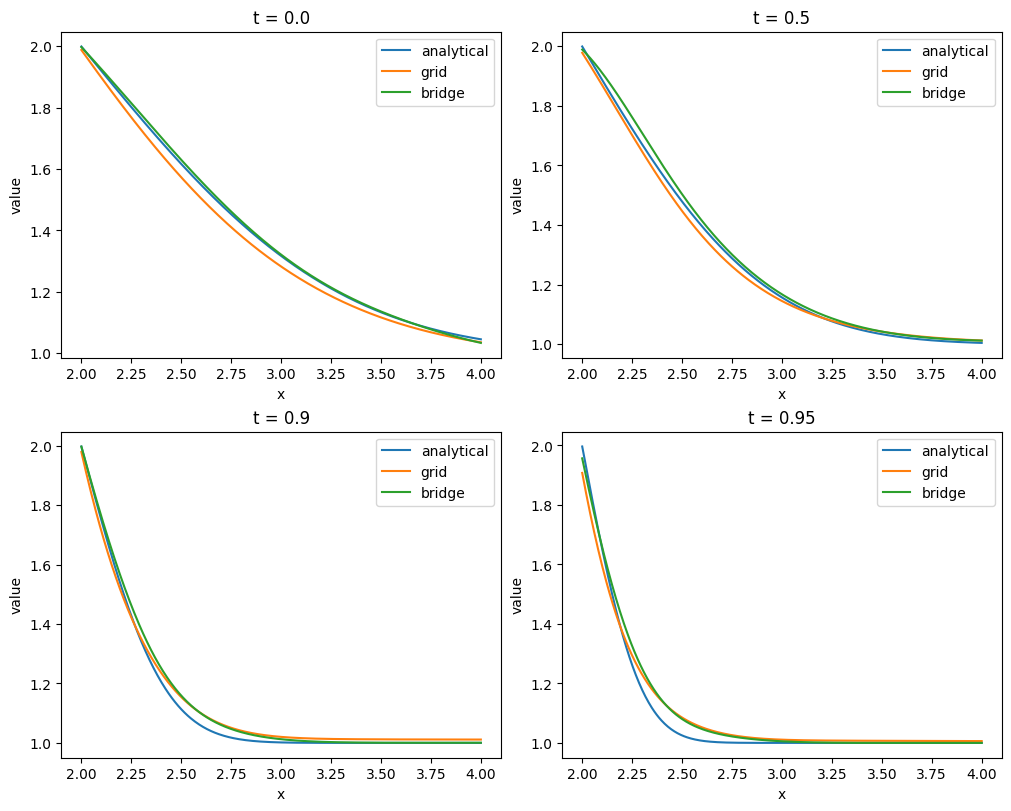

In [19]:
x_plot = torch.linspace(2.001, CFG.n2_x_max, 500, device=DEVICE, dtype=DTYPE)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, t in zip(axes.flat, CFG.validation_times):
    ax.plot(to_numpy(x_plot), to_numpy(exact_singleton(2, t, x_plot)), label="analytical")
    ax.plot(to_numpy(x_plot), to_numpy(grid_singleton.value(t, x_plot)), label="grid")
    ax.plot(to_numpy(x_plot), to_numpy(models2[1].value(t, x_plot)), label="bridge")
    ax.set_title(f"t = {t}")
    ax.set_xlabel("x")
    ax.set_ylabel("value")
    ax.legend()

plt.show()
plt.close(fig)

## N = 2 exact-geometry reference

In [20]:
@torch.no_grad()
def exact_n2_domain(points):
    return points.min(dim=1).values > CFG.alpha * exact_singleton(
        2, 0.0, points.max(dim=1).values
    )


@torch.no_grad()
def reference_payoff(points, dW, t0=0.0):
    p, paths, steps = points.shape[0], dW.shape[0], dW.shape[1]

    x = points[:, None, :].expand(p, paths, 2).clone()
    active = torch.ones(p, paths, device=DEVICE, dtype=torch.bool)
    payoff = torch.zeros(p, paths, device=DEVICE, dtype=DTYPE)
    dt = (CFG.T - t0) / steps

    for k in range(steps + 1):
        t = t0 + k * dt
        large = x.max(dim=2).values
        hit = active & (x.min(dim=2).values <= CFG.alpha * exact_singleton(2, t, large))

        if bool(hit.any()):
            payoff[hit] = exact_singleton(2, t, large[hit])
            active[hit] = False

        if k < steps:
            x = x + CFG.sigma * dW[:, k][None, :, :]

    return payoff


@torch.no_grad()
def reference_surface(points, mask, dW, half):
    value = exact_singleton(2, 0.0, points.max(dim=1).values)
    se = torch.zeros_like(value)
    inside = points[mask]

    estimates, errors, pairs = [], [], []
    for start in range(0, len(inside), CFG.reference_point_batch):
        sample = reference_payoff(inside[start:start + CFG.reference_point_batch], dW)
        pair = 0.5 * (sample[:, :half] + sample[:, half:])
        estimates.append(pair.mean(dim=1))
        errors.append(pair.std(dim=1, unbiased=True) / math.sqrt(half))
        pairs.append(pair.cpu())

    value[mask] = torch.cat(estimates)
    se[mask] = torch.cat(errors)

    return value, se, torch.cat(pairs, dim=0)


@torch.no_grad()
def make_reference(models, x_max):
    axis = torch.linspace(CFG.x_min, x_max, CFG.reference_grid, device=DEVICE, dtype=DTYPE)
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)
    mask = exact_n2_domain(points)

    steps = sorted(CFG.reference_steps)
    fine = steps[-1]
    if any(fine % k for k in steps):
        raise ValueError("every reference resolution must divide the finest one")

    half = CFG.reference_paths // 2
    g = make_generator(SEED + 20_000)
    normal = torch.randn(half, fine, 2, generator=g, device=DEVICE, dtype=DTYPE)
    fine_dW = math.sqrt(CFG.T / fine) * torch.cat((normal, -normal))

    value, se, pairs = {}, {}, {}
    for k in steps:
        dW = fine_dW.reshape(CFG.reference_paths, k, fine // k, 2).sum(dim=2)
        value[k], se[k], pairs[k] = reference_surface(points, mask, dW, half)

    return {
        "axis": axis,
        "points": points,
        "mask": mask,
        "half": half,
        "value": value,
        "se": se,
        "pairs": pairs,
        "learned": completed_value(2, 2, 0.0, points, models),
    }


def richardson(reference, coarse, fine):
    ratio = math.sqrt(fine / coarse)
    a, b = ratio / (ratio - 1.0), -1.0 / (ratio - 1.0)

    value = a * reference["value"][fine] + b * reference["value"][coarse]
    pair = a * reference["pairs"][fine] + b * reference["pairs"][coarse]

    se = torch.zeros_like(value)
    se[reference["mask"]] = (
        pair.std(dim=1, unbiased=True) / math.sqrt(reference["half"])
    ).to(DEVICE, DTYPE)

    return value, se, pair


def error_row(name, learned, reference, mask, se=None):
    error = learned[mask] - reference[mask]

    return {
        "reference": name,
        "MAE": error.abs().mean().item(),
        "RMSE": error.square().mean().sqrt().item(),
        "signed mean": error.mean().item(),
        "max error": error.abs().max().item(),
        "mean MC SE": se[mask].mean().item() if se is not None else math.nan,
        "max MC SE": se[mask].max().item() if se is not None else math.nan,
    }


reference2 = make_reference(models2, CFG.n2_x_max)
mask2 = reference2["mask"]
rich_value, rich_se, rich_pairs = richardson(reference2, 40, 400)

print("interior grid points", int(mask2.sum()), "of", len(mask2))

interior grid points 1838 of 2601


### Monitoring law and Richardson check

In [21]:
steps_sorted = sorted(CFG.reference_steps)

law_rows = []
for coarse, fine in zip(steps_sorted[:-1], steps_sorted[1:]):
    gap = (reference2["value"][fine] - reference2["value"][coarse])[mask2].mean().item()
    scale = 1.0 / math.sqrt(coarse) - 1.0 / math.sqrt(fine)
    law_rows.append({"coarse": coarse, "fine": fine, "mean gap": gap, "implied c": gap / scale})

show("first-passage bias constant", pd.DataFrame(law_rows), 5)

fine_value, _, _ = richardson(reference2, steps_sorted[-2], steps_sorted[-1])
proxy_gap = (rich_value - fine_value)[mask2]

proxy_check = pd.DataFrame([{
    "comparison": f"R({steps_sorted[0]},{steps_sorted[1]}) minus R({steps_sorted[-2]},{steps_sorted[-1]})",
    "MAE": proxy_gap.abs().mean().item(),
    "signed mean": proxy_gap.mean().item(),
    "max": proxy_gap.abs().max().item(),
}])
show("Richardson proxy check", proxy_check, 5)


first-passage bias constant
 coarse  fine  mean gap  implied c
     40   400   0.04091    0.37840
    400  4000   0.01260    0.36862

Richardson proxy check
                 comparison     MAE  signed mean     max
R(40,400) minus R(400,4000) 0.00431      0.00049 0.03811


### Field errors

In [22]:
reference_table = pd.DataFrame([
    error_row("40", reference2["learned"], reference2["value"][40], mask2, reference2["se"][40]),
    error_row("400", reference2["learned"], reference2["value"][400], mask2, reference2["se"][400]),
    error_row("Richardson", reference2["learned"], rich_value, mask2, rich_se),
])
show("N = 2 field error on the exact continuation region", reference_table)

movement = pd.DataFrame([
    {
        "comparison": "40 to 400",
        "MAE": (reference2["value"][40] - reference2["value"][400])[mask2].abs().mean().item(),
    },
    {
        "comparison": "400 to Richardson",
        "MAE": (reference2["value"][400] - rich_value)[mask2].abs().mean().item(),
    },
])
show("reference movement", movement)


N = 2 field error on the exact continuation region
 reference    MAE   RMSE  signed mean  max error  mean MC SE  max MC SE
        40 0.0681 0.0759       0.0671     0.1959      0.0096     0.0136
       400 0.0276 0.0303       0.0262     0.0946      0.0094     0.0135
Richardson 0.0130 0.0154       0.0073     0.0607      0.0104     0.0154

reference movement
       comparison    MAE
        40 to 400 0.0409
400 to Richardson 0.0189


In [23]:
plateau_mask = (reference2["points"] <= 2.0 * CFG.alpha).all(dim=1)
killed_mask = (~mask2) & (~plateau_mask)


def region_row(name, mask):
    error = (reference2["learned"] - reference2["value"][400])[mask]
    return {
        "region": name,
        "grid points": int(mask.sum().item()),
        "grid fraction": mask.to(DTYPE).mean().item(),
        "MAE": error.abs().mean().item(),
        "RMSE": error.square().mean().sqrt().item(),
        "signed mean": error.mean().item(),
    }


show(
    "N = 2 error by region",
    pd.DataFrame([
        region_row("exact continuation region", mask2),
        region_row("killed region excluding the plateau", killed_mask),
        region_row("exact plateau [1,2]^2", plateau_mask),
    ]),
)


N = 2 error by region
                             region  grid points  grid fraction    MAE   RMSE  signed mean
          exact continuation region         1838         0.7067 0.0276 0.0303       0.0262
killed region excluding the plateau          474         0.1822 0.0082 0.0094       0.0076
              exact plateau [1,2]^2          289         0.1111 0.0000 0.0000       0.0000


### Reference Monte Carlo uncertainty

In [24]:
def bootstrap_mae(learned, pairs, reps, seed):
    learned = learned.detach().cpu()
    pairs = pairs.detach().cpu()
    half = pairs.shape[1]
    g = torch.Generator().manual_seed(seed)

    values = torch.empty(reps, dtype=pairs.dtype)
    for b in range(reps):
        index = torch.randint(0, half, (half,), generator=g)
        values[b] = (learned - pairs[:, index].mean(dim=1)).abs().mean()

    return {
        "bootstrap SE of MAE": values.std(unbiased=True).item(),
        "MAE 2.5%": torch.quantile(values, 0.025).item(),
        "MAE 97.5%": torch.quantile(values, 0.975).item(),
    }


learned_inside = reference2["learned"][mask2]
observed = dict(zip(reference_table["reference"], reference_table["MAE"]))

bootstrap_rows = []
for offset, (name, pairs) in enumerate(
    (("40", reference2["pairs"][40]), ("400", reference2["pairs"][400]), ("Richardson", rich_pairs))
):
    row = {"reference": name, "observed MAE": observed[name]}
    row.update(bootstrap_mae(learned_inside, pairs, CFG.bootstrap_reps, SEED + 70_000 + offset))
    row["bootstrap SE / MAE"] = row["bootstrap SE of MAE"] / row["observed MAE"]
    bootstrap_rows.append(row)

bootstrap_table = pd.DataFrame(bootstrap_rows)
show("reference bootstrap", bootstrap_table, 6)

for _, row in bootstrap_table.iterrows():
    if row["bootstrap SE / MAE"] >= 0.25:
        print(
            f"warning [{row['reference']}]: bootstrap SE is "
            f"{row['bootstrap SE / MAE']:.1%} of the observed MAE"
        )


reference bootstrap
 reference  observed MAE  bootstrap SE of MAE  MAE 2.5%  MAE 97.5%  bootstrap SE / MAE
        40      0.068119             0.003629  0.061476   0.075327            0.053276
       400      0.027648             0.003489  0.021368   0.034416            0.126188
Richardson      0.013026             0.002633  0.010749   0.020920            0.202161


### Propagation of frozen-field error

In [25]:
control_learned = completed_value(2, 2, 0.0, reference2["points"], models2_control)
perturbed_learned = completed_value(2, 2, 0.0, reference2["points"], models2_perturbed)

control_table = pd.DataFrame([
    error_row("400", control_learned, reference2["value"][400], mask2, reference2["se"][400]),
    error_row("Richardson", control_learned, rich_value, mask2, rich_se),
])
show("exact-singleton-lower control against the same references", control_table)

singleton_t0 = bridge_metrics.loc[bridge_metrics["time"] == 0.0].iloc[0]
shift_error = (perturbed_learned - control_learned)[mask2]
inherited_error = (reference2["learned"] - control_learned)[mask2]

propagation = pd.DataFrame([
    {
        "lower-level perturbation": f"analytic singleton + {CFG.perturbation}",
        "input error": CFG.perturbation,
        "level-two MAE": shift_error.abs().mean().item(),
        "level-two signed mean": shift_error.mean().item(),
        "amplification": shift_error.abs().mean().item() / CFG.perturbation,
    },
    {
        "lower-level perturbation": "learned singleton",
        "input error": singleton_t0["MAE"],
        "level-two MAE": inherited_error.abs().mean().item(),
        "level-two signed mean": inherited_error.mean().item(),
        "amplification": inherited_error.abs().mean().item() / singleton_t0["MAE"],
    },
])
show("one-level error propagation", propagation, 5)
print(
    "\nheuristic amplification at t = 0:",
    round(1.0 + 0.8 * CFG.alpha / (CFG.sigma * math.sqrt(CFG.T)), 4),
)
print(
    "the shift is overridden below the boundary and at T, so it acts only on the interior"
)


exact-singleton-lower control against the same references
 reference    MAE   RMSE  signed mean  max error  mean MC SE  max MC SE
       400 0.0236 0.0258       0.0220     0.0696      0.0094     0.0135
Richardson 0.0117 0.0142       0.0031     0.0587      0.0104     0.0154

one-level error propagation
 lower-level perturbation  input error  level-two MAE  level-two signed mean  amplification
analytic singleton + 0.05      0.05000        0.05133                0.05133        1.02667
        learned singleton      0.00659        0.00662                0.00425        1.00434

heuristic amplification at t = 0: 1.8
the shift is overridden below the boundary and at T, so it acts only on the interior


In [26]:
def paired_difference(main, control, pairs, reps, seed):
    main, control, pairs = main.detach().cpu(), control.detach().cpu(), pairs.detach().cpu()
    half = pairs.shape[1]
    g = torch.Generator().manual_seed(seed)

    values = torch.empty(reps, dtype=pairs.dtype)
    for b in range(reps):
        index = torch.randint(0, half, (half,), generator=g)
        reference_b = pairs[:, index].mean(dim=1)
        values[b] = (main - reference_b).abs().mean() - (control - reference_b).abs().mean()

    return {
        "mean difference": values.mean().item(),
        "bootstrap SE": values.std(unbiased=True).item(),
        "2.5%": torch.quantile(values, 0.025).item(),
        "97.5%": torch.quantile(values, 0.975).item(),
    }


control_inside = control_learned[mask2]
difference_rows = []
for offset, (name, pairs) in enumerate(
    (("400", reference2["pairs"][400]), ("Richardson", rich_pairs))
):
    row = {"reference": name}
    row.update(
        paired_difference(
            learned_inside, control_inside, pairs, CFG.bootstrap_reps, SEED + 71_000 + offset
        )
    )
    difference_rows.append(row)

show("main minus control MAE, paired reference bootstrap", pd.DataFrame(difference_rows), 6)


main minus control MAE, paired reference bootstrap
 reference  mean difference  bootstrap SE      2.5%   97.5%
       400         0.003810      0.000344  0.003064 0.00420
Richardson         0.001037      0.000909 -0.000800 0.00277


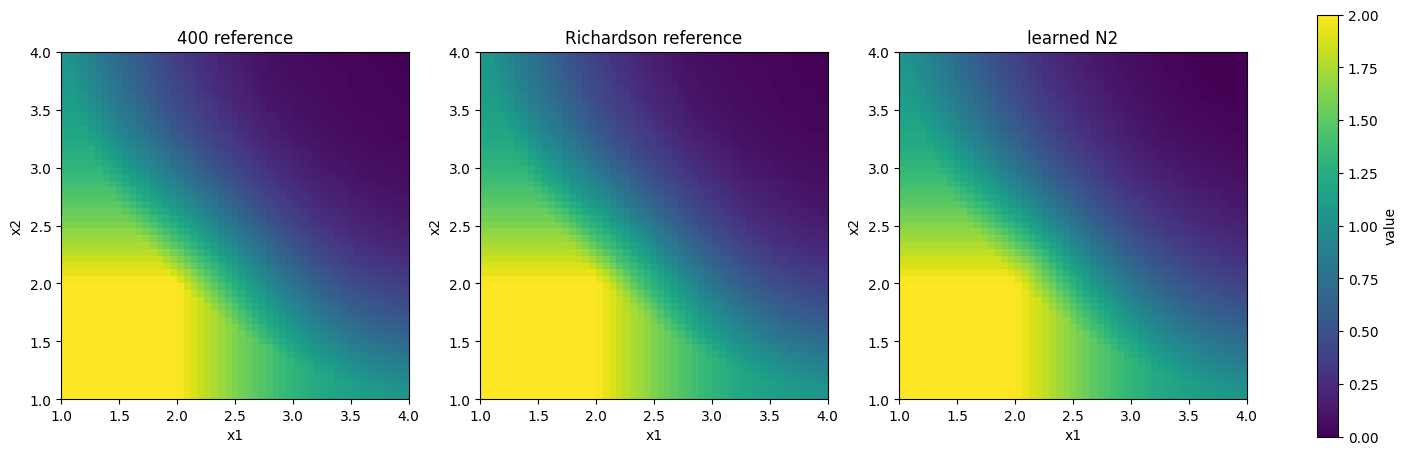

In [27]:
axis = to_numpy(reference2["axis"])
size = CFG.reference_grid

fields = [
    (to_numpy(reference2["value"][400]).reshape(size, size), "400 reference"),
    (to_numpy(rich_value).reshape(size, size), "Richardson reference"),
    (to_numpy(reference2["learned"]).reshape(size, size), "learned N2"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
for ax, (values, title) in zip(axes, fields):
    image = ax.imshow(
        values.T,
        origin="lower",
        extent=(axis[0], axis[-1], axis[0], axis[-1]),
        aspect="equal",
        vmin=0.0,
        vmax=2.0,
    )
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig.colorbar(image, ax=axes, label="value")
plt.show()
plt.close(fig)

### Time evolution of the reference

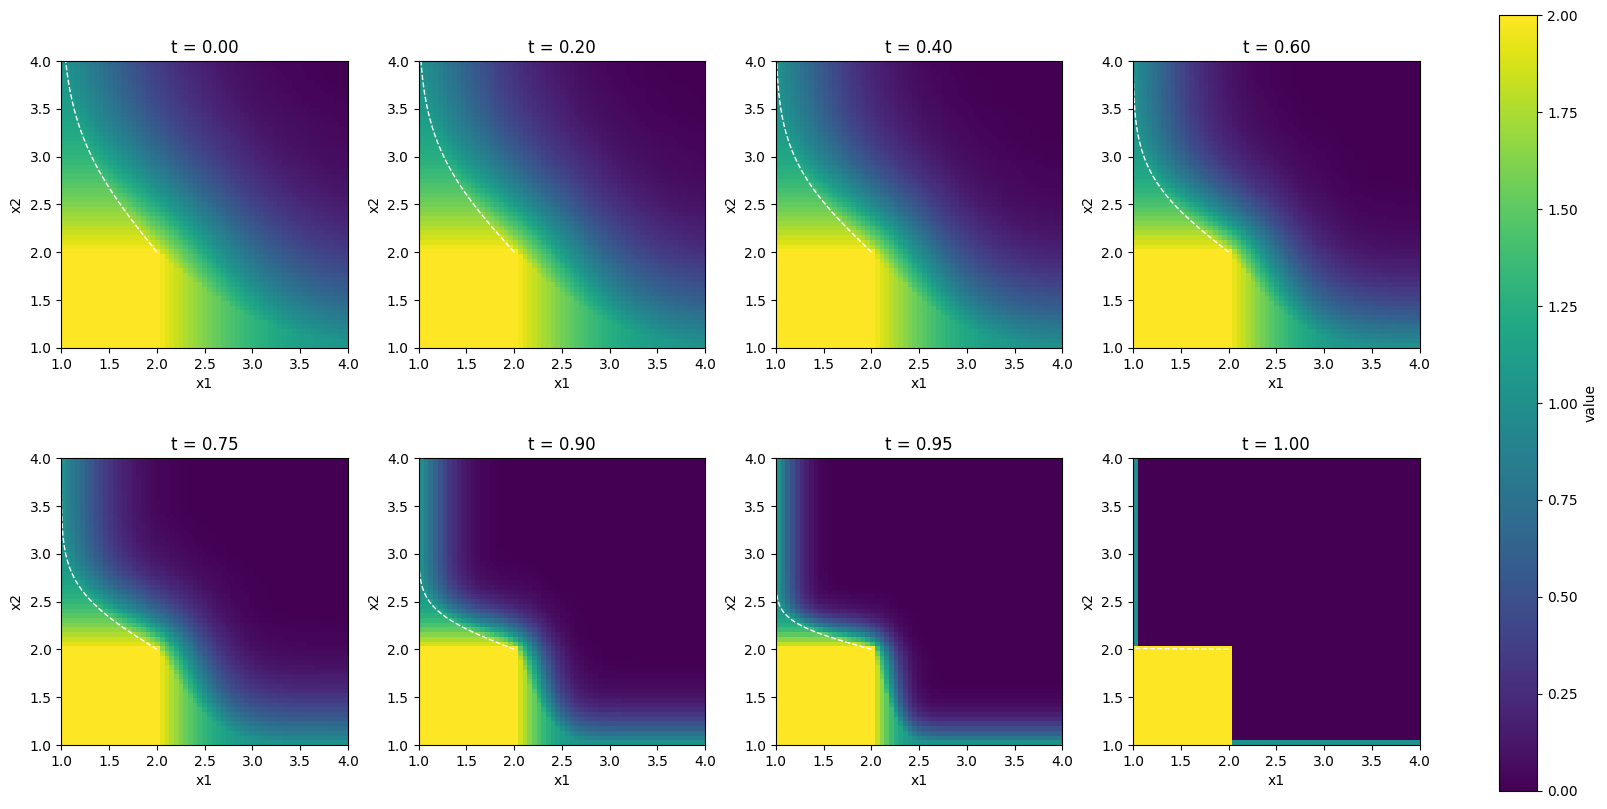

In [28]:
evolution_times = (0.0, 0.2, 0.4, 0.6, 0.75, 0.9, 0.95, 1.0)
grid_size = 61
steps_evolution = 400

axis_e = torch.linspace(CFG.x_min, CFG.n2_x_max, grid_size, device=DEVICE, dtype=DTYPE)
x1, x2 = torch.meshgrid(axis_e, axis_e, indexing="ij")
points_e = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)

half_e = CFG.reference_paths // 2
g_e = make_generator(SEED + 21_000)
normal_e = torch.randn(half_e, steps_evolution, 2, generator=g_e, device=DEVICE, dtype=DTYPE)
normal_e = torch.cat((normal_e, -normal_e))

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)

for ax, t0 in zip(axes.flat, evolution_times):
    large = points_e.max(dim=1).values
    inside = points_e.min(dim=1).values > CFG.alpha * exact_singleton(2, t0, large)
    field = exact_singleton(2, t0, large).clone()

    if t0 >= CFG.T or not bool(inside.any()):
        field[inside] = 0.0
    else:
        dW_e = math.sqrt((CFG.T - t0) / steps_evolution) * normal_e
        estimates = []
        for start in range(0, int(inside.sum()), CFG.reference_point_batch):
            chunk = points_e[inside][start:start + CFG.reference_point_batch]
            estimates.append(reference_payoff(chunk, dW_e, t0).mean(dim=1))
        field[inside] = torch.cat(estimates)

    image = ax.imshow(
        to_numpy(field).reshape(grid_size, grid_size).T,
        origin="lower",
        extent=(CFG.x_min, CFG.n2_x_max, CFG.x_min, CFG.n2_x_max),
        aspect="equal",
        vmin=0.0,
        vmax=2.0,
    )

    curve = torch.linspace(2.0 * CFG.alpha, CFG.n2_x_max, 200, device=DEVICE, dtype=DTYPE)
    ax.plot(
        to_numpy(CFG.alpha * exact_singleton(2, t0, curve)),
        to_numpy(curve),
        "--",
        color="white",
        linewidth=1.0,
    )
    ax.set_title(f"t = {t0:.2f}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig.colorbar(image, ax=axes, label="value")
plt.show()
plt.close(fig)

## N = 3 cascade

In [29]:
models3, training3 = train_cascade(3, CFG.n3_x_max, SEED + 5_000)

show("N = 3 training", training_table(3, training3))

show(
    "N = 3 leakage",
    pd.concat(
        [
            leakage_diagnostic(3, 2, models3, CFG.n3_x_max, SEED + 61_000),
            leakage_diagnostic(3, 3, models3, CFG.n3_x_max, SEED + 62_000),
        ],
        ignore_index=True,
    ),
    6,
)

N 3 level 1 2000 2.1148e-02
N 3 level 1 4000 1.3801e-02
N 3 level 1 6000 1.1523e-02
N 3 level 1 8000 9.9019e-03
N 3 level 1 10000 9.2102e-03
N 3 level 1 12000 9.3180e-03
N 3 level 1 14000 8.3654e-03
N 3 level 1 15000 8.0795e-03
N 3 level 2 2000 1.5949e-01
N 3 level 2 4000 6.5937e-02
N 3 level 2 6000 2.6420e-02
N 3 level 2 8000 2.0478e-02
N 3 level 2 10000 1.7141e-02
N 3 level 2 12000 1.4540e-02
N 3 level 2 14000 1.3557e-02
N 3 level 2 15000 1.3591e-02
N 3 level 3 2000 2.4158e-01
N 3 level 3 4000 1.0959e-01
N 3 level 3 6000 7.4989e-02
N 3 level 3 8000 4.1741e-02
N 3 level 3 10000 3.2861e-02
N 3 level 3 12000 2.7638e-02
N 3 level 3 14000 2.8122e-02
N 3 level 3 15000 2.3782e-02

N = 3 training
 N  level  best iteration  best validation  stopped  stopped_immediate  stopped_rollout  immediate_exit_fraction  living   exit  boundary  near_terminal  range  monotonicity  shape_in_domain
 3      1           15000           0.0081   0.0063             0.0000           0.0063                   0.0

### N = 3 singleton

In [30]:
n3_singleton_full = singleton_table(3, models3[1], CFG.n3_x_max)
n3_singleton_scaled = singleton_table(3, models3[1], 3.0 * CFG.alpha + CFG.singleton_window)

show("N = 3 singleton, full training range", n3_singleton_full)
show("N = 3 singleton, window scaled with sigma sqrt(T)", n3_singleton_scaled)


N = 3 singleton, full training range
 time    MAE   RMSE  signed mean  max error  Z MAE
 0.00 0.0084 0.0099       0.0057     0.0185 0.0215
 0.50 0.0055 0.0086       0.0038     0.0264 0.0225
 0.90 0.0120 0.0187       0.0115     0.0488 0.0288
 0.95 0.0148 0.0283       0.0146     0.0999 0.0547

N = 3 singleton, window scaled with sigma sqrt(T)
 time    MAE   RMSE  signed mean  max error  Z MAE
 0.00 0.0094 0.0110       0.0086     0.0185 0.0309
 0.50 0.0080 0.0116       0.0048     0.0264 0.0412
 0.90 0.0197 0.0261       0.0187     0.0488 0.0553
 0.95 0.0258 0.0399       0.0253     0.0999 0.1077


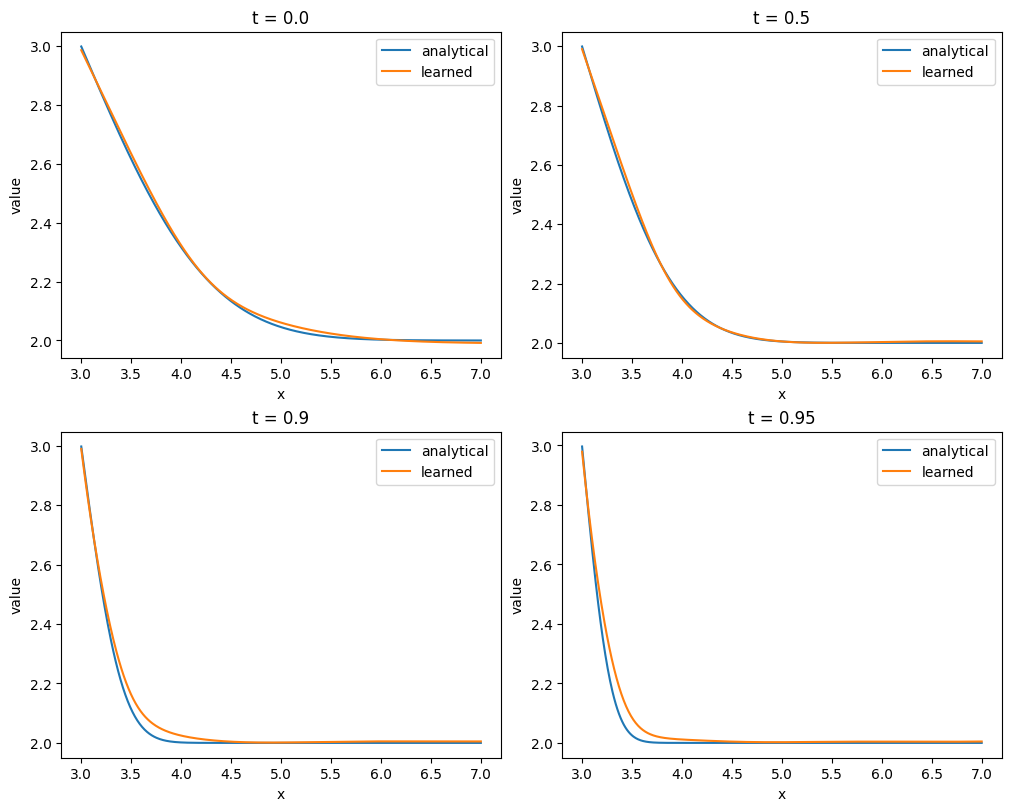

In [31]:
x = torch.linspace(3.001, CFG.n3_x_max, 500, device=DEVICE, dtype=DTYPE)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, t in zip(axes.flat, CFG.validation_times):
    ax.plot(to_numpy(x), to_numpy(exact_singleton(3, t, x)), label="analytical")
    ax.plot(to_numpy(x), to_numpy(models3[1].value(t, x)), label="learned")
    ax.set_title(f"t = {t}")
    ax.set_xlabel("x")
    ax.set_ylabel("value")
    ax.legend()

plt.show()
plt.close(fig)

### Learned level-three moving boundary

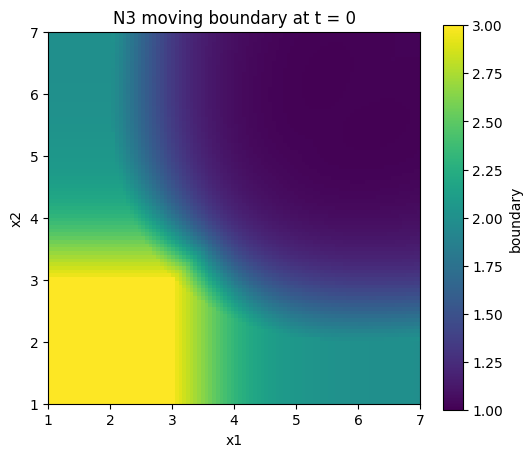

In [32]:
axis = torch.linspace(CFG.x_min, CFG.n3_x_max, 100, device=DEVICE, dtype=DTYPE)
x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)

boundary = CFG.alpha * completed_value(3, 2, 0.0, points, models3).clamp(1.0, 3.0)
axis_np = to_numpy(axis)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(
    to_numpy(boundary).reshape(100, 100).T,
    origin="lower",
    extent=(axis_np[0], axis_np[-1], axis_np[0], axis_np[-1]),
    aspect="equal",
    vmin=1.0,
    vmax=3.0,
)
fig.colorbar(image, ax=ax, label="boundary")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("N3 moving boundary at t = 0")

plt.show()
plt.close(fig)

### Three-to-two dimensional reduction

In [33]:
@torch.no_grad()
def projection_check(far_values):
    g = make_generator(SEED + 40_000)
    retained = uniform((CFG.projection_samples, 2), 2.5, CFG.n2_x_max, g)

    n2_field = completed_value(2, 2, 0.0, retained, models2)
    n2_boundary = CFG.alpha * completed_value(
        2, 1, 0.0, retained[:, 0:1], models2
    ).clamp(1.0, 2.0)

    rows = []
    for L in far_values:
        far = torch.full((CFG.projection_samples, 1), L, device=DEVICE, dtype=DTYPE)

        n3_field = completed_value(3, 3, 0.0, torch.cat((retained, far), dim=1), models3)
        n3_boundary = CFG.alpha * completed_value(
            3, 2, 0.0, torch.cat((retained[:, 0:1], far), dim=1), models3
        ).clamp(1.0, 3.0)

        field_error = n3_field - n2_field
        boundary_error = n3_boundary - n2_boundary
        z = (CFG.alpha * 3.0 - L) / (CFG.sigma * math.sqrt(CFG.T))

        rows.append({
            "L": L,
            "direct-hit bound": 2.0 * float(normal_cdf(torch.tensor(z))),
            "field MAE": field_error.abs().mean().item(),
            "field RMSE": field_error.square().mean().sqrt().item(),
            "boundary MAE": boundary_error.abs().mean().item(),
            "boundary RMSE": boundary_error.square().mean().sqrt().item(),
        })

    return pd.DataFrame(rows)


projection = projection_check(CFG.projection_far)
show("N = 3 to N = 2 reduction", projection, 6)
print("\nthe largest L lies on the edge of the N = 3 training box")


N = 3 to N = 2 reduction
  L  direct-hit bound  field MAE  field RMSE  boundary MAE  boundary RMSE
6.0          0.002700   0.009018    0.011581      0.015041       0.017234
6.5          0.000465   0.008824    0.010527      0.015452       0.018245
7.0          0.000063   0.010454    0.012488      0.024874       0.026392

the largest L lies on the edge of the N = 3 training box


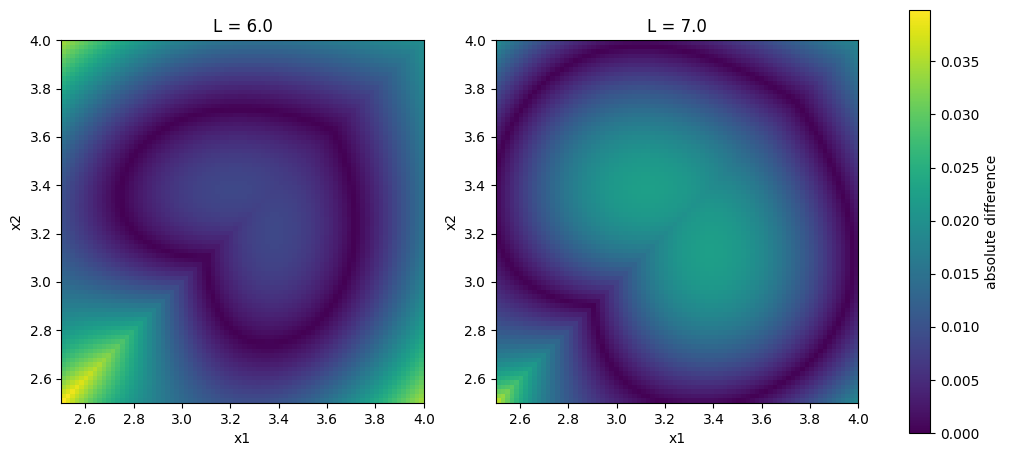

In [34]:
axis = torch.linspace(2.5, CFG.n2_x_max, 80, device=DEVICE, dtype=DTYPE)
x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
points2 = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)
n2_field = completed_value(2, 2, 0.0, points2, models2)

shown = (CFG.projection_far[0], CFG.projection_far[-1])
errors = []
for L in shown:
    far = torch.full((points2.shape[0], 1), L, device=DEVICE, dtype=DTYPE)
    n3_field = completed_value(3, 3, 0.0, torch.cat((points2, far), dim=1), models3)
    errors.append((n3_field - n2_field).abs())

vmax = max(float(e.max()) for e in errors)
axis_np = to_numpy(axis)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, L, error in zip(axes, shown, errors):
    image = ax.imshow(
        to_numpy(error).reshape(80, 80).T,
        origin="lower",
        extent=(axis_np[0], axis_np[-1], axis_np[0], axis_np[-1]),
        aspect="equal",
        vmin=0.0,
        vmax=vmax,
    )
    ax.set_title(f"L = {L}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig.colorbar(image, ax=axes, label="absolute difference")
plt.show()
plt.close(fig)

## Multiple-boundary consistency

In [35]:
kink_results = pd.DataFrame([
    kink_check(2, 2, models2, CFG.n2_x_max, CFG.kink_tolerance),
    kink_check(3, 2, models3, CFG.n3_x_max, CFG.kink_tolerance),
    kink_check(3, 3, models3, CFG.n3_x_max, CFG.kink_tolerance),
    kink_check(2, 2, models2, CFG.n2_x_max, None),
    kink_check(3, 2, models3, CFG.n3_x_max, None),
    kink_check(3, 3, models3, CFG.n3_x_max, None),
])
show("compatibility of alternative reductions", kink_results, 6)


compatibility of alternative reductions
 N  level  tolerance  retained points  mean spread  max spread
 2      2       0.05              297     0.000000    0.000000
 3      2       0.05               74     0.000000    0.000000
 3      3       0.05              212     0.000031    0.004153
 2      2        inf           111102     0.000000    0.000000
 3      2        inf           110760     0.000000    0.000000
 3      3        inf           112792     0.000000    0.004153


## Seed study

In [36]:
seed_rows = []

for seed in CFG.seed_study_seeds:
    seed_models = models2 if seed == SEED else train_cascade(2, CFG.n2_x_max, seed)[0]

    singleton = singleton_table(2, seed_models[1], CFG.n2_x_max)
    at_zero = singleton.loc[singleton["time"] == 0.0].iloc[0]

    error = (completed_value(2, 2, 0.0, reference2["points"], seed_models) - rich_value)[mask2]

    seed_rows.append({
        "seed": seed,
        "singleton MAE at t = 0": at_zero["MAE"],
        "singleton signed mean at t = 0": at_zero["signed mean"],
        "field MAE vs Richardson": error.abs().mean().item(),
        "field signed mean vs Richardson": error.mean().item(),
    })

seed_study = pd.DataFrame(seed_rows)
show("N = 2 seed study", seed_study, 5)
show(
    "N = 2 seed study summary",
    seed_study.drop(columns="seed").agg(["mean", "min", "max"]).reset_index().rename(
        columns={"index": "statistic"}
    ),
    5,
)

N 2 level 1 2000 2.6039e-02
N 2 level 1 4000 1.6733e-02
N 2 level 1 6000 1.4546e-02
N 2 level 1 8000 1.3079e-02
N 2 level 1 10000 1.2283e-02
N 2 level 1 12000 1.1928e-02
N 2 level 1 14000 1.1713e-02
N 2 level 1 15000 1.1755e-02
N 2 level 2 2000 6.7628e-02
N 2 level 2 4000 3.7594e-02
N 2 level 2 6000 3.0132e-02
N 2 level 2 8000 2.6364e-02
N 2 level 2 10000 2.3253e-02
N 2 level 2 12000 2.2339e-02
N 2 level 2 14000 2.1202e-02
N 2 level 2 15000 2.0835e-02
N 2 level 1 2000 2.5801e-02
N 2 level 1 4000 1.9855e-02
N 2 level 1 6000 1.5994e-02
N 2 level 1 8000 1.4413e-02
N 2 level 1 10000 1.2774e-02
N 2 level 1 12000 1.3229e-02
N 2 level 1 14000 1.1958e-02
N 2 level 1 15000 1.2065e-02
N 2 level 2 2000 8.1077e-02
N 2 level 2 4000 4.9284e-02
N 2 level 2 6000 3.2529e-02
N 2 level 2 8000 2.6130e-02
N 2 level 2 10000 2.2990e-02
N 2 level 2 12000 2.1495e-02
N 2 level 2 14000 2.0505e-02
N 2 level 2 15000 2.0233e-02

N = 2 seed study
 seed  singleton MAE at t = 0  singleton signed mean at t = 0  field M

## Volatility stress test

In [37]:
with override_config(
    sigma=CFG.volatility_sigma,
    n2_x_max=CFG.volatility_x_max,
    reference_steps=(40, 400),
):
    print("kappa", CFG.alpha / (CFG.sigma * math.sqrt(CFG.T)))

    models2_low, training2_low = train_cascade(2, CFG.n2_x_max, SEED + 80_000)
    window = 2.0 * CFG.alpha + CFG.singleton_window

    low_singleton = singleton_table(2, models2_low[1], window)
    low_predicted = continuity_correction_table(2, window)

    low_reference = make_reference(models2_low, CFG.n2_x_max)
    low_rich, low_rich_se, _ = richardson(low_reference, 40, 400)

    low_table = pd.DataFrame([
        error_row(
            "400",
            low_reference["learned"],
            low_reference["value"][400],
            low_reference["mask"],
            low_reference["se"][400],
        ),
        error_row(
            "Richardson", low_reference["learned"], low_rich, low_reference["mask"], low_rich_se
        ),
    ])

comparison = (
    low_singleton[["time", "MAE", "signed mean"]]
    .merge(low_predicted, on="time")
    .merge(predicted.rename(columns={"predicted grid MAE": "predicted at sigma 1"}), on="time")
)

show("sigma = 0.3 singleton on the scaled window", comparison, 5)
show("sigma = 0.3 field error", low_table)

kappa 3.3333333333333335
N 2 level 1 2000 1.8424e-02
N 2 level 1 4000 1.3388e-02
N 2 level 1 6000 1.0816e-02
N 2 level 1 8000 9.4313e-03
N 2 level 1 10000 8.7364e-03
N 2 level 1 12000 8.2608e-03
N 2 level 1 14000 7.8367e-03
N 2 level 1 15000 7.8170e-03
N 2 level 2 2000 1.7949e-01
N 2 level 2 4000 6.2196e-02
N 2 level 2 6000 3.5484e-02
N 2 level 2 8000 3.0053e-02
N 2 level 2 10000 2.6922e-02
N 2 level 2 12000 2.1759e-02
N 2 level 2 14000 1.9843e-02
N 2 level 2 15000 1.9312e-02

sigma = 0.3 singleton on the scaled window
 time     MAE  signed mean  predicted grid MAE  predicted at sigma 1
 0.00 0.00566      0.00494             0.04243               0.04247
 0.50 0.01119      0.00908             0.03118               0.03123
 0.90 0.01480      0.01271             0.01396               0.01403
 0.95 0.02087      0.02011             0.00985               0.00992

sigma = 0.3 field error
 reference    MAE   RMSE  signed mean  max error  mean MC SE  max MC SE
       400 0.0299 0.0467       0.

## Summary

In [38]:
kappa = CFG.alpha / (CFG.sigma * math.sqrt(CFG.T))

show(
    "parameters",
    pd.DataFrame({
        "quantity": [
            "alpha", "sigma", "T", "kappa", "kappa N for N2", "kappa N for N3",
            "monitoring intervals", "restart strata", "maximum restart time",
            "near-terminal time", "near-terminal spatial guard",
            "near-terminal guard in diffusive s.d.",
            "N2 training box upper limit", "N3 training box upper limit",
        ],
        "value": [
            CFG.alpha, CFG.sigma, CFG.T, kappa, 2.0 * kappa, 3.0 * kappa,
            CFG.steps, CFG.restart_levels, CFG.max_restart_time,
            CFG.T - CFG.terminal_epsilon, CFG.terminal_margin, CFG.terminal_guard_std,
            CFG.n2_x_max, CFG.n3_x_max,
        ],
    }),
)


parameters
                             quantity  value
                                alpha   1.00
                                sigma   1.00
                                    T   1.00
                                kappa   1.00
                       kappa N for N2   2.00
                       kappa N for N3   3.00
                 monitoring intervals  40.00
                       restart strata  41.00
                 maximum restart time   0.95
                   near-terminal time   0.99
          near-terminal spatial guard   0.40
near-terminal guard in diffusive s.d.   4.00
          N2 training box upper limit   4.00
          N3 training box upper limit   7.00


In [39]:
def lookup(table, column, key_column, key):
    return float(table.loc[table[key_column] == key, column].iloc[0])


kink_row = kink_results[
    (kink_results["N"] == 3)
    & (kink_results["level"] == 3)
    & (kink_results["tolerance"] == CFG.kink_tolerance)
].iloc[0]

show(
    "summary",
    pd.DataFrame({
        "quantity": [
            "N2 grid singleton MAE at t = 0",
            "N2 bridge singleton MAE at t = 0",
            "N2 bridge singleton signed mean at t = 0",
            "N2 bridge singleton Z MAE at t = 0",
            "N2 field MAE against 40 reference",
            "N2 field MAE against 400 reference",
            "N2 field MAE against Richardson reference",
            "N2 field bootstrap SE of MAE against Richardson",
            "N2 exact-lower control MAE against Richardson",
            "one-level amplification, known 0.05 shift",
            "one-level amplification, learned singleton",
            "Richardson proxy check, signed mean",
            "N3 singleton MAE at t = 0 on the scaled window",
            "N3 to N2 field MAE at the smallest L",
            "N3 to N2 field MAE at the largest L",
            "N3 level 3 kink mean spread",
            "N3 level 3 kink max spread",
        ],
        "value": [
            lookup(grid_metrics, "MAE", "time", 0.0),
            lookup(bridge_metrics, "MAE", "time", 0.0),
            lookup(bridge_metrics, "signed mean", "time", 0.0),
            lookup(bridge_metrics, "Z MAE", "time", 0.0),
            lookup(reference_table, "MAE", "reference", "40"),
            lookup(reference_table, "MAE", "reference", "400"),
            lookup(reference_table, "MAE", "reference", "Richardson"),
            lookup(bootstrap_table, "bootstrap SE of MAE", "reference", "Richardson"),
            lookup(control_table, "MAE", "reference", "Richardson"),
            float(propagation["amplification"].iloc[0]),
            float(propagation["amplification"].iloc[1]),
            float(proxy_check["signed mean"].iloc[0]),
            lookup(n3_singleton_scaled, "MAE", "time", 0.0),
            lookup(projection, "field MAE", "L", CFG.projection_far[0]),
            lookup(projection, "field MAE", "L", CFG.projection_far[-1]),
            float(kink_row["mean spread"]),
            float(kink_row["max spread"]),
        ],
    }),
    6,
)


summary
                                       quantity    value
                 N2 grid singleton MAE at t = 0 0.027504
               N2 bridge singleton MAE at t = 0 0.006595
       N2 bridge singleton signed mean at t = 0 0.004731
             N2 bridge singleton Z MAE at t = 0 0.021246
              N2 field MAE against 40 reference 0.068119
             N2 field MAE against 400 reference 0.027648
      N2 field MAE against Richardson reference 0.013026
N2 field bootstrap SE of MAE against Richardson 0.002633
  N2 exact-lower control MAE against Richardson 0.011736
      one-level amplification, known 0.05 shift 1.026672
     one-level amplification, learned singleton 1.004337
            Richardson proxy check, signed mean 0.000489
 N3 singleton MAE at t = 0 on the scaled window 0.009450
           N3 to N2 field MAE at the smallest L 0.009018
            N3 to N2 field MAE at the largest L 0.010454
                    N3 level 3 kink mean spread 0.000031
                     N